In [1]:
import pandas as pd

encoded_df = pd.read_csv("encoded_network_features.csv")

In [2]:
encoded_df.head()


,enc1,enc2,enc3,enc4,enc5,Label
0,4.490305,1.356725,4.282272,5.004297,0.257939,0
1,4.396287,0.980978,4.062100,4.662739,0.387258,0
2,4.091665,0.762624,3.782046,4.389673,0.334870,0
3,3.642728,0.858193,3.222756,4.029458,0.352682,0
4,4.490354,1.356788,4.282147,5.004299,0.257971,0


In [3]:
X = encoded_df.drop(columns=['Label'])
y = encoded_df['Label'] #SEPERATING LABELS

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [5]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=150,
    max_depth=20,
    min_samples_split=5,
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)

,n_estimators,150
,criterion,'gini'
,max_depth,20
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [6]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = rf.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[451633   2632]
 [  1464 109847]]
              precision    recall  f1-score   support

           0       1.00      0.99      1.00    454265
           1       0.98      0.99      0.98    111311

    accuracy                           0.99    565576
   macro avg       0.99      0.99      0.99    565576
weighted avg       0.99      0.99      0.99    565576



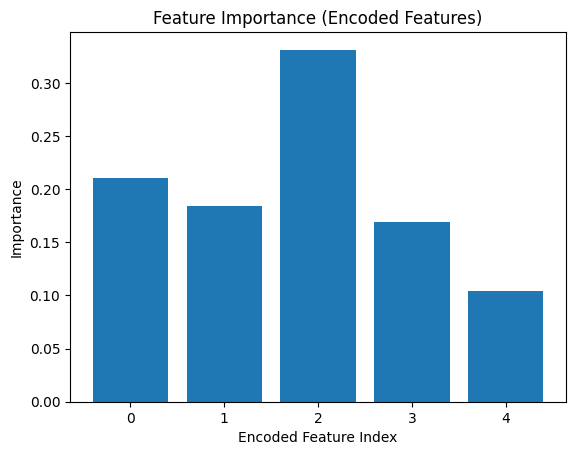

In [7]:
import matplotlib.pyplot as plt

importances = rf.feature_importances_

plt.bar(range(len(importances)), importances)
plt.title("Feature Importance (Encoded Features)")
plt.xlabel("Encoded Feature Index")
plt.ylabel("Importance")
plt.show()

In [8]:
y_train_pred = rf.predict(X_train)

print(classification_report(y_train, y_train_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1817055
           1       0.98      0.99      0.99    445245

    accuracy                           0.99   2262300
   macro avg       0.99      0.99      0.99   2262300
weighted avg       0.99      0.99      0.99   2262300



In [9]:
import joblib

joblib.dump(rf, "rf_model.pkl")

['rf_model.pkl']

In [10]:
joblib.dump(list(X.columns), "feature_columns.pkl") 

['feature_columns.pkl']